# Remote Sensing Image Segmentation
The goal here is to use any remote sensing image segmentation data, randomly sample the simulated point label, and add the loss to any remote sensing segmentation network. Thus, we will implement a segmentation model for remote sensing images on GID-15 data images, then train, evaluate and test it on the GID-15 dataset and analyze the impact of various factors on the model's performance.

## Install Libraries and Dependencies

In [2]:
!pip install -U torch torchvision albumentations matplotlib mlflow scikit-learn segmentation-models-pytorch 

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.5/41.5 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.0/66.0 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 766.7/766.7 MB 2.2 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.2 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 99.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 77.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.0 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/

In [7]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [8]:
!pip install google-api-core>=2.10.2

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models.segmentation as models
from torch.utils.data import DataLoader, Dataset
import numpy as np
import random
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from sklearn.model_selection import train_test_split

import mlflow
import mlflow.pytorch

### Random Tiling(Patch)
This is to help reduce the file size of the images

In [6]:
# We define a helper function for Random Tiling(Patching)
def random_tile(image, mask, sparse_mask, patch_size=512):
    """
    Extract a random square patch of size patch_size x patch_size from the input image,
    mask, and sparse_mask. If the image dimensions are smaller than the patch size,
    the original inputs are returned unchanged.

    Parameters:
        image: The RGB image as a NumPy array.
        mask: The corresponding ground truth mask.
        sparse_mask: The sparse version of the mask.
        patch_size: The size of the patch to extract. Default is 512.

    Returns:
        patch_image, patch_mask, patch_sparse_mask (representing the extracted patch).
    """
    height, width, _ = image.shape
    # If the image is smaller than the patch size, return the original image and masks
    if height <= patch_size or width <= patch_size:
        return image, mask, sparse_mask

    # choosing a random top-left cordinate for the patch
    y_start = random.randint(0, height - patch_size)
    x_start = random.randint(0, width - patch_size)

    # we extract the patch from image, mask, and sparse_mask 
    patch_image = image[y_start:y_start + patch_size, x_start:x_start + patch_size, :]
    patch_mask = mask[y_start:y_start + patch_size, x_start:x_start + patch_size]
    patch_sparse_mask = sparse_mask[y_start:y_start + patch_size, x_start:x_start + patch_size]
    
    return patch_image, patch_mask, patch_sparse_mask

## Defining Dataset Class for Training/Validation

In [9]:
# We Define the Dataset Class for Training/Validation
class RemoteSensingDataset(Dataset):
    """
    A dataset class for remote sensing images and their corresponding masks.
    
    Each sample consists of an RGB image, a ground truth mask (with class labels), 
    and a simulated sparse label map for weak supervision.
    """
    
    def __init__(self, image_paths, mask_paths, transform=None, total_points=500, patch_size=512):
        """
        Parameters:
            image_paths: List of paths to the images.
            mask_paths: List of paths to the ground truth masks.
            transform: Function for data augmentation.
            total_points: Number of points to sample from the ground truth.
            patch_size: Size of the square patch to extract.
        """

        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform
        self.total_points = total_points
        self.patch_size = patch_size

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Load the full image and ground truth mask (grey_gt)
        image = np.array(Image.open(self.image_paths[idx]).convert("RGB"))
        mask = np.array(Image.open(self.mask_paths[idx]).convert("L"), dtype=np.uint8)
        # Noting that for GID-15 dataset, masks use 0 for background and 1–15 for land-cover classes.
        # So we Map labeled pixels: subtract 1 from nonzero pixels (so 1-15 become 0-14)
        mask = np.where(mask > 0, mask - 1, mask)
        
        # Simulating(to generate) sparse point labels (using a subset of the GT pixels)
        sparse_mask = self.simulate_point_labels(mask, self.total_points)
        
        # Extract a random patch of patch size 512×512
        image, mask, sparse_mask = random_tile(image, mask, sparse_mask, self.patch_size)
        
        # Applying any specified transformation
        if self.transform:
            augmented = self.transform(image=image, mask=mask, mask2=sparse_mask)
            image = augmented['image']
            mask = augmented['mask']
            sparse_mask = augmented['mask2']
        return image, sparse_mask

    def simulate_point_labels(self, mask, total_points=500):
        """
        Simulates sparse labeling by sampling a subset of pixels from the full mask.
        Ensures each unique class in the mask is represented by at least one point.
        
        Parameters:
            mask: The ground truth mask (2D array).
            total_points: Total number of points to sample.
        
        Returns:
            An array of a sparse mask with only the sampled class labels.
        """       
        height, weight = mask.shape
        sparse_mask = np.zeros((height, weight), dtype=np.uint8)
        unique_classes = np.unique(mask)
        selected_points = []

        # Ensure at least one point is sampled for each class.
        for class_value in unique_classes:
            class_pixels = np.argwhere(mask == class_value)
            if len(class_pixels) > 0:
                sampled_pixel = class_pixels[random.randint(0, len(class_pixels)-1)]
                sparse_mask[sampled_pixel[0], sampled_pixel[1]] = class_value
                selected_points.append(sampled_pixel)

        # Sample additional points up to the specified total
        max_points = min(total_points, height * weight)
        valid_pixels = np.argwhere(mask > 0)
        for _ in range(max_points - len(selected_points)):
            idx = valid_pixels[random.randint(0, len(valid_pixels)-1)]
            sparse_mask[idx[0], idx[1]] = mask[idx[0], idx[1]]
        return sparse_mask


## Defining Test Dataset Class for inference only

In [10]:
# Defining Test Dataset
class TestDataset(Dataset):
    def __init__(self, image_paths, transform=None, patch_size=512):
        """
        To initialize the test dataset.

        Parameters:
            image_paths: file paths to the test images.
            transform function to apply to each image
            patch_size: size in pixels of the square patch to extract
        """
        self.image_paths = image_paths
        self.transform = transform
        self.patch_size = patch_size

    def __len__(self):
        # Return the total number of images
        return len(self.image_paths)

    def __getitem__(self, idx):
        """
        Retrieve and process the image at the specified index.

        How we go about it:
            1. Load the image in RGB format.
            2. Extract a random patch from the image using the provided patch_size.
            3. Apply a transformation to the patch.
            4. Return the processed patch along with its file path.

        Parameters:
            idx: Index of the image in the dataset.

        Returns:
            (processed_image, file_path)
        """
        image = np.array(Image.open(self.image_paths[idx]).convert("RGB"))
        # Extract one random tile for inference
        image, _, _ = random_tile(image, image, image, self.patch_size)

        # Apply the transformation if provided
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']

        # Return the processed image along with its original file path
        return image, self.image_paths[idx]  # return filename for saving predictions


## Data Augmentations

In [11]:
# Defining our Augmentations

# defining training and validation data augmentation
train_val_transforms = A.Compose([
    A.Resize(256, 256),       # Resize image and masks to 256x256 pixels
    A.HorizontalFlip(p=0.5),  # Randomly flip horizontally with a 50% chance
    A.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5]),   
    ToTensorV2()               # convert image to pytorch tensor.
], additional_targets={'mask2': 'mask'}) # apply same transformations to 'mask2'


# defining test augmentations
test_transforms = A.Compose([
    A.Resize(256, 256),  # resize image
    A.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5]),
    ToTensorV2()   # convert image to tensor
])


## Dataset directories and paths

In [12]:
# Train, Validation and Test data paths
train_img_dir = "/kaggle/input/remote-sensing-gid15/gid-15/GID/img_dir/train"
train_mask_dir = "/kaggle/input/remote-sensing-gid15/gid-15/GID/ann_dir/train"
val_img_dir   = "/kaggle/input/remote-sensing-gid15/gid-15/GID/img_dir/val"
val_mask_dir  = "/kaggle/input/remote-sensing-gid15/gid-15/GID/ann_dir/val"
test_img_dir  = "/kaggle/input/remote-sensing-gid15/gid-15/GID/img_dir/test"  # noting that test set has no Ground Truth

train_image_paths = [os.path.join(train_img_dir, f) for f in os.listdir(train_img_dir)]
train_mask_paths  = [os.path.join(train_mask_dir, f) for f in os.listdir(train_mask_dir) if f.endswith(".png")]
val_image_paths   = [os.path.join(val_img_dir, f) for f in os.listdir(val_img_dir)]
val_mask_paths    = [os.path.join(val_mask_dir, f) for f in os.listdir(val_mask_dir) if f.endswith(".png")]
test_image_paths  = [os.path.join(test_img_dir, f) for f in os.listdir(test_img_dir)]

# dataset with defined transformations
train_dataset = RemoteSensingDataset(train_image_paths, train_mask_paths, transform=train_val_transforms, patch_size=512)
val_dataset   = RemoteSensingDataset(val_image_paths, val_mask_paths, transform=train_val_transforms, patch_size=512)
test_dataset  = TestDataset(test_image_paths, transform=test_transforms, patch_size=512)


## Partial Cross-Entropy Loss for sparse annotations.

This loss function computes the standard cross-entropy loss only on the positions where the target label is not equal to a specified ignore index. This is particularly useful when working with sparse annotations where only a subset of the pixels should contribute to the loss.

In [13]:
# Defining Partial Cross-Entropy Loss (for our sparse annotations)
class PartialCrossEntropyLoss(nn.Module):
    """
    Partial Cross-Entropy Loss for sparse annotations.

    Partial Entropy loss function computes the standard cross-entropy loss only on 
    the positions where the target label is not equal to a specified 
    ignore index.
    """
    def __init__(self, ignore_index=0): # ignore pixels with label 0 (background)
        super(PartialCrossEntropyLoss, self).__init__()
        self.ignore_index = ignore_index
        # setting reduction to 'none' to compute loss for each element seperately
        self.criterion = nn.CrossEntropyLoss(reduction='none')
        
    def forward(self, predictions, target):
        """
        params:
            predictions which are the model's output logits of shape (N, Class, Height, Width)

        returns an average loss computed only over the valid pixels
        """
        # compute element-wise cross-entropy loss
        loss = self.criterion(predictions, target)
        # create mask which is valid where target is not the ignore_index
        valid_mask = (target != self.ignore_index).float()
        
        return torch.sum(loss * valid_mask) / (torch.sum(valid_mask) + 1e-6) # partial CE loss with epsilon to avoid division by zero

## Build and return a U-Net model configured for the GID-15 dataset.

This U-Net model uses a ResNet34 encoder and is tailored for segmentation tasks on our GID-15 dataset. It produces 15 output channels corresponding to 15 land-cover classes (with 0 reserved for background).


In [14]:
# Defining the model function to retrieve U-Net for our GID-15 dataset with 15 output classes
def get_model():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # tailor smp U-Net for 15 output classes (1-15; 0 is background) of our GID-15 dataset
    model = smp.Unet(encoder_name="resnet34", encoder_weights=None, in_channels=3, classes=15, activation=None)

    model.to(device)
    return model

## Setting up mlflow UI

In [15]:
# installing ngrok for serving our mlflow UI
!pip install pyngrok --quiet

In [22]:
get_ipython().system_raw("mlflow ui --port 5000 &")
mlflow.pytorch.autolog()

2025/02/23 21:13:20 WARNING mlflow.utils.autologging_utils: MLflow pytorch autologging is known to be compatible with 1.9.0 <= torch <= 2.5.1, but the installed version is 2.6.0+cu124. If you encounter errors during autologging, try upgrading / downgrading torch to a compatible version, or try upgrading MLflow.


In [23]:
from pyngrok import ngrok
from getpass import getpass

# Terminate open tunnels if exist
ngrok.kill()

# Setting the authtoken saved on kaggle secrets
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("ngrok_auth")

# Get your authtoken from https://dashboard.ngrok.com/auth
NGROK_AUTH_TOKEN = secret_value_0
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

# Open an HTTPs tunnel on port 5000 for http://localhost:5000
ngrok_tunnel = ngrok.connect(addr="5000", proto="http", bind_tls=True)
print("MLflow Tracking UI:", ngrok_tunnel.public_url)

MLflow Tracking UI: https://7d42-35-247-17-141.ngrok-free.app


## Training Function
Training a segmentation model using training and validation data loaders while tracking parameters and metrics with MLflow. This function logs hyperparameters, training and validation losses for each epoch, and saves the final trained model as an artifact.

It returns the trained model.

In [18]:
# Train the Model with MLflow Tracking (includes Training & Validation)
def train_model(model, train_loader, val_loader, generator, num_epochs=10, lr=0.001):
    """
    Training function with parameters:
        model: segementation model to be trained(in this case U-Net)
        train_loader: Dataloader for training dataset
        val_loader: Dataloader for validation dataset
        num_epochs: number of epochs to train
        lr: learning rate for optimizer

    returns:
        torch.nn.Module: The trained model
    """
    # set up computation device to use GPU if available, else CPU
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # force all tensors to be on GPU by default
    if torch.cuda.is_available():
        torch.set_default_device("cuda")
    
    # initialize model and move to gpu
    model = model.to(device)

    # Initialize optimizer and custom loss function(Partial CE loss) 
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = PartialCrossEntropyLoss()

    train_losses = []
    val_losses = []

    # Training loop
    for epoch in range(num_epochs):
        model.train() # sets training mode
        train_loss = 0
        total_labeled_pixels = 0  
        batches = 0

        # iterate over batches from training data loader
        for images, masks in train_loader:
            print("Unique mask values:", torch.unique(masks.to(device)))
            images = images.to(device, dtype=torch.float32)
            masks= masks.to(device, dtype=torch.long)

            # reset gradients
            optimizer.zero_grad() 

            # forward pass
            outputs = model(images)  # outputs: [B, 15, H, W]

            # compute loss
            loss = criterion(outputs, masks)

            # Calculate the number of labeled (valid) pixels in the batch:
            valid_mask = (masks != criterion.ignore_index).float()
            labeled_pixel_count = torch.sum(valid_mask).item()
            total_labeled_pixels += labeled_pixel_count
            batches += 1
            
            # backward pass
            loss.backward()

            # update model parameters
            optimizer.step()
            train_loss += loss.item()
            
        avg_train_loss = train_loss / len(train_loader)
        train_losses.append(avg_train_loss) # store train loss
        avg_labeled_pixels = total_labeled_pixels / batches if batches > 0 else 0

        
        # Validation loop
        model.eval() # evluation mode
        val_loss = 0
        with torch.no_grad():
            for images, masks in val_loader:
                images = images.to(device, dtype=torch.float32)
                masks= masks.to(device, dtype=torch.long)
                
                outputs = model(images)
                loss = criterion(outputs, masks)
                val_loss += loss.item()
        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss) # store validation losses
        
        print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f}")
        print(f"Avg labeled pixels per batch: {avg_labeled_pixels:.0f}")
        
        # log metrics for the current epoch
        mlflow.log_metric("train_loss", avg_train_loss, step=epoch)
        mlflow.log_metric("val_loss", avg_val_loss, step=epoch)
        mlflow.log_metric("avg_labeled_pixels", avg_labeled_pixels, step=epoch)
    
    return model, train_losses, val_losses

# Test Evaluation

## Test Evaluation Function
Evaluate model on test dataset using partial cross-entropy loss. The function computes the loss over test dataset without gradient tracking,and returns the average test loss.

In [19]:
# Test Evaluation
def test_model(model, test_loader):
    """
    Evaluates the model on test dataset.

    Since the test dataset returns (image, filename) (with no ground truth masks),
    this function will simply generate predictions and return them.
    """
    # set device to use GPU if available, otherwise go back to using cpu 
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    model = model.to(device)
    model.eval()
    all_predictions = []  # list to store predictions along with filenames
    
    
    # disable gradient computation for predicting images
    with torch.no_grad():
        for images, filename in test_loader:
            # Here, meta is the filename (a string)
            images = images.to(device, dtype=torch.float32)
            
            # forward pass
            outputs = model(images)

            predictions = torch.argmax(outputs, dim=1).cpu().numpy()
            # Store predictions along with filenames
            all_predictions.append((predictions, filename))
    
    return all_predictions


### Hyperparameter Tuning Pipeline
We incorporate hyperparameter tuning and tracking through MLFlow to help optimize model performance on the GID‑15 dataset. We can then select the best segmentation model with optimal parameters on the GID‑15 dataset.

In [ ]:
# Set the experiment name for hyperparameter tuning
mlflow.set_experiment("GID15_Unet_HyperparameterTuning")

# Define hyperparameter grids (customize these values as needed)
learning_rates = [0.001, 0.0005]
batch_sizes = [8, 16]
num_epochs = 10

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create a generator on the correct device
generator = torch.Generator(device=device)
generator.manual_seed(42)  

all_run_losses = {}

# Loop over each combination of hyperparameters
for lr in learning_rates:
    for bs in batch_sizes:
        run_name = f"lr_{lr}_bs_{bs}"
        print(f"\nStarting run: {run_name}")
        
        with mlflow.start_run(run_name=run_name) as run:
            # Log hyperparameters
            mlflow.log_param("learning_rate", lr)
            mlflow.log_param("batch_size", bs)
            mlflow.log_param("num_epochs", num_epochs)
            mlflow.log_param("patch_size", 512)

            # Create dataloaders with current batch size to iterate over datasets
            train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True, generator=generator)
            val_loader   = DataLoader(val_dataset, batch_size=bs, shuffle=False, generator=generator)
            
            # Initialize a new model for each run
            model = get_model()
            
            # Train the model using the defined training function (which also logs training and validation losses)
            trained_model, train_losses, val_losses = train_model(model, train_loader, val_loader, generator, num_epochs=num_epochs, lr=lr)

            # Log the final trained model as an artifact
            mlflow.pytorch.log_model(trained_model, artifact_path="model")

            # Store the losses externally
            all_run_losses[run_name] = {"train_losses": train_losses, "val_losses": val_losses}
            
            print(f"Run {run_name} completed.")
            


Starting run: lr_0.001_bs_8
Unique mask values: tensor([0, 1, 5, 8], device='cuda:0', dtype=torch.uint8)
Unique mask values: tensor([0, 1, 5], device='cuda:0', dtype=torch.uint8)
Unique mask values: tensor([0, 6, 8], device='cuda:0', dtype=torch.uint8)
Unique mask values: tensor([0, 2, 5], device='cuda:0', dtype=torch.uint8)
Unique mask values: tensor([0, 5, 8], device='cuda:0', dtype=torch.uint8)
Unique mask values: tensor([ 0,  2,  6,  7,  8, 12, 13], device='cuda:0', dtype=torch.uint8)
Unique mask values: tensor([0, 1, 9], device='cuda:0', dtype=torch.uint8)
Unique mask values: tensor([0, 6, 9], device='cuda:0', dtype=torch.uint8)
Unique mask values: tensor([0, 5, 6], device='cuda:0', dtype=torch.uint8)
Unique mask values: tensor([0, 5], device='cuda:0', dtype=torch.uint8)
Unique mask values: tensor([0, 1, 5, 6, 8, 9], device='cuda:0', dtype=torch.uint8)
Unique mask values: tensor([0, 4, 5], device='cuda:0', dtype=torch.uint8)
Unique mask values: tensor([0, 1, 3, 5, 6], device='cud

2025/02/23 22:53:51 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Run lr_0.001_bs_8 completed.

Starting run: lr_0.001_bs_16
Unique mask values: tensor([0, 1, 4, 5, 6, 8, 9], device='cuda:0', dtype=torch.uint8)
Unique mask values: tensor([0, 1, 5, 6, 9], device='cuda:0', dtype=torch.uint8)
Unique mask values: tensor([ 0,  2,  5,  6,  8, 12], device='cuda:0', dtype=torch.uint8)
Unique mask values: tensor([ 0,  1,  2,  4,  5,  8,  9, 13], device='cuda:0', dtype=torch.uint8)
Unique mask values: tensor([ 0,  2,  3,  5, 13], device='cuda:0', dtype=torch.uint8)
Unique mask values: tensor([ 0,  5,  6,  8, 10, 12, 13], device='cuda:0', dtype=torch.uint8)
Unique mask values: tensor([0, 8, 9], device='cuda:0', dtype=torch.uint8)
Epoch 1/10 - Train Loss: 2.8343 - Val Loss: 80.2549
Avg labeled pixels per batch: 10
Unique mask values: tensor([0, 1, 2, 3, 5, 6, 9], device='cuda:0', dtype=torch.uint8)
Unique mask values: tensor([ 0,  1,  2,  3,  5,  7,  8, 12], device='cuda:0', dtype=torch.uint8)
Unique mask values: tensor([ 0,  2,  5,  6, 13], device='cuda:0', dty

### Retrieve best model from mlflow

In [26]:
from mlflow.tracking import MlflowClient

# Retrieve the experiment by name
experiment = mlflow.get_experiment_by_name("GID15_Unet_HyperparameterTuning")

# Search for best run based on lowest validation loss
runs_df = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string="",
    order_by=["metrics.val_loss ASC"],
    max_results=1
)
best_run_id = runs_df.iloc[0]["run_id"]
print("Best run ID:", best_run_id)

# Load the model logged in that best run
model_uri = f"runs:/{best_run_id}/model"
best_model = mlflow.pytorch.load_model(model_uri)

Best run ID: 5a91204031684f9a9ae1a3df23236ad9


In [43]:
print("Best run model info", best_run)

Best run model info <Run: data=<RunData: metrics={'avg_labeled_pixels': 9.142857142857142,
 'train_loss': 2.230884449822562,
 'val_loss': 1.5941272974014282}, params={'batch_size': '16',
 'learning_rate': '0.001',
 'num_epochs': '10',
 'patch_size': '512'}, tags={'mlflow.log-model.history': '[{"run_id": "5a91204031684f9a9ae1a3df23236ad9", '
                             '"artifact_path": "model", "utc_time_created": '
                             '"2025-02-24 00:33:26.070716", "model_uuid": '
                             '"991462e62dd04b74a261fad2343eff30", "flavors": '
                             '{"pytorch": {"model_data": "data", '
                             '"pytorch_version": "2.6.0+cu124", "code": null}, '
                             '"python_function": {"pickle_module_name": '
                             '"mlflow.pytorch.pickle_module", "loader_module": '
                             '"mlflow.pytorch", "python_version": "3.10.12", '
                             '"data": "dat

In [34]:
# get best run name and batch size
client = MlflowClient()
best_run = client.get_run(best_run_id)  # best_run_id obtained earlier
bs = int(best_run.data.params["batch_size"])
print("Batch size used in best run:", bs)
run_name = best_run.data.tags.get("mlflow.runName")
print("Best run name:", run_name)

Batch size used in best run: 16
Best run name: lr_0.001_bs_16


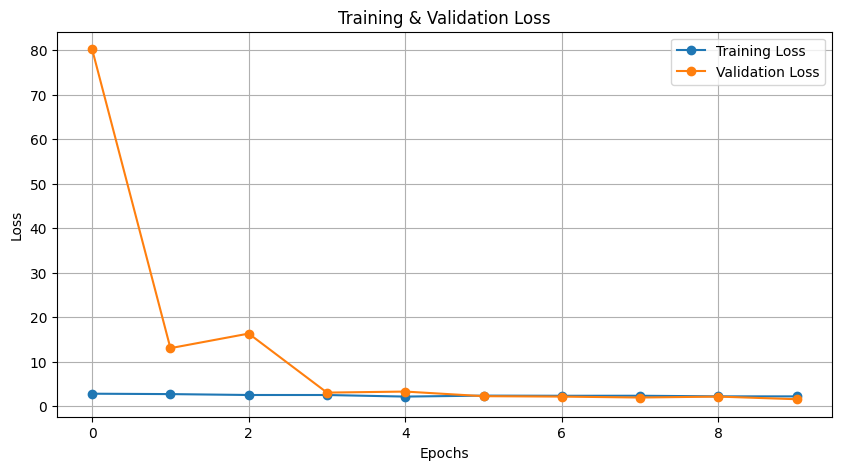

In [38]:
# plot losses
def plot_losses(train_losses, val_losses):
    """
    Plots the training and validation loss curves.

    Parameters:
        train_losses: list of training loss per epoch.
        val_losses: list of validation loss per epoch.
    """
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label="Training Loss", marker='o')
    plt.plot(val_losses, label="Validation Loss", marker='o')
    plt.title("Training & Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid()
    plt.show()

best_run_losses = all_run_losses[run_name]
plot_losses(best_run_losses["train_losses"], best_run_losses["val_losses"])

## Visualization Functions
### Validation set visualization
This function visualizes a batch of predictions alongside original images and sparse ground truth masks.
It retrieves one batch from the provided dataloader, passes the images through the model to obtain predictions, and displays the original images, sparse annotations, and predicted segmentation maps side-by-side using matplotlib.
This is to help compare the model's predictions against ground truth labels thus, we make use of the validation dataloader that provides ground truth.

### Test set predictions Visualize Function
Visualizes predictions on the test set. It assumes that the dataloader returns (image, filename) and no ground truth.

In [39]:
# Visualization to compare models predictions against ground truth labels
def visualize_predictions(model, dataloader):
    """
    Visualizes a batch of predictions alongside original images and sparse ground truth masks.

    This function retrieves one batch from the provided dataloader, passes the images through
    the model to obtain predictions, and displays the original images, sparse annotations, and
    predicted segmentation maps side-by-side using matplotlib.

    Parameters:
        model: trained segmentation model.
        dataloader: DataLoader for the dataset to visualize.
    """
    # set model to evaluation mode
    model.eval()

    # determine either GPU or CPU
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # disable gradient computations for inference
    with torch.no_grad():
        # process only first batch from dataloader
        for images, masks in dataloader:
            # move images to selected device
            images = images.to(device)
            # compute model outputs
            outputs = model(images)
            # convert logits to predicted class labels
            predictions = torch.argmax(outputs, dim=1).cpu().numpy()
            # determine batch size
            batch_size = images.size(0)
            # create subplot with 3 rows (original, sparse labels, Predictions)
            # and as many columns as there are images in the batch
            fig, axes = plt.subplots(3, batch_size, figsize=(15, 5))

            for i in range(batch_size):
                # convert image tensor to Numpy array
                image_np = images[i].permute(1, 2, 0).cpu().numpy()
                axes[0, i].imshow(image_np)
                axes[0, i].set_title("Original Image")
                axes[0, i].axis("off")

                # display the sparse labels (grayscale)
                axes[1, i].imshow(masks[i].cpu().numpy(), cmap="gray")
                axes[1, i].set_title("Sparse Labels")
                axes[1, i].axis("off")

                # display predicted segementation
                axes[2, i].imshow(predictions[i], cmap="gray")
                axes[2, i].set_title("Prediction")
                axes[2, i].axis("off")

            plt.tight_layout()
            plt.show()
            break  # to visualize only one batch


def visualize_test_predictions(test_predictions):
    """
    Visualizes predictions on the test set.
    Assumes that the dataloader returns (image, filename).
    """
    # Loop over each batch (if more than one batch is returned)
    for predictions, filenames in test_predictions:
        batch_size = predictions.shape[0]
        fig, axes = plt.subplots(1, batch_size, figsize=(4 * batch_size, 4))
        if batch_size == 1:
            axes = [axes]  # Ensure axes is iterable if only one image
        for i in range(batch_size):
            axes[i].imshow(predictions[i], cmap="gray")
            axes[i].set_title(filenames[i])
            axes[i].axis("off")
        plt.tight_layout()
        plt.show()
        break  # Visualize only the first batch

# Model Predictions

## Visualizing model predictions

### Visualizing  the model predictions on validation set
We visualize the predictions from the best model alongside original images and sparse ground truth masks to help compare the model's predictions against ground truth labels. Thus, we make use of the validation dataloader that provides ground truth.

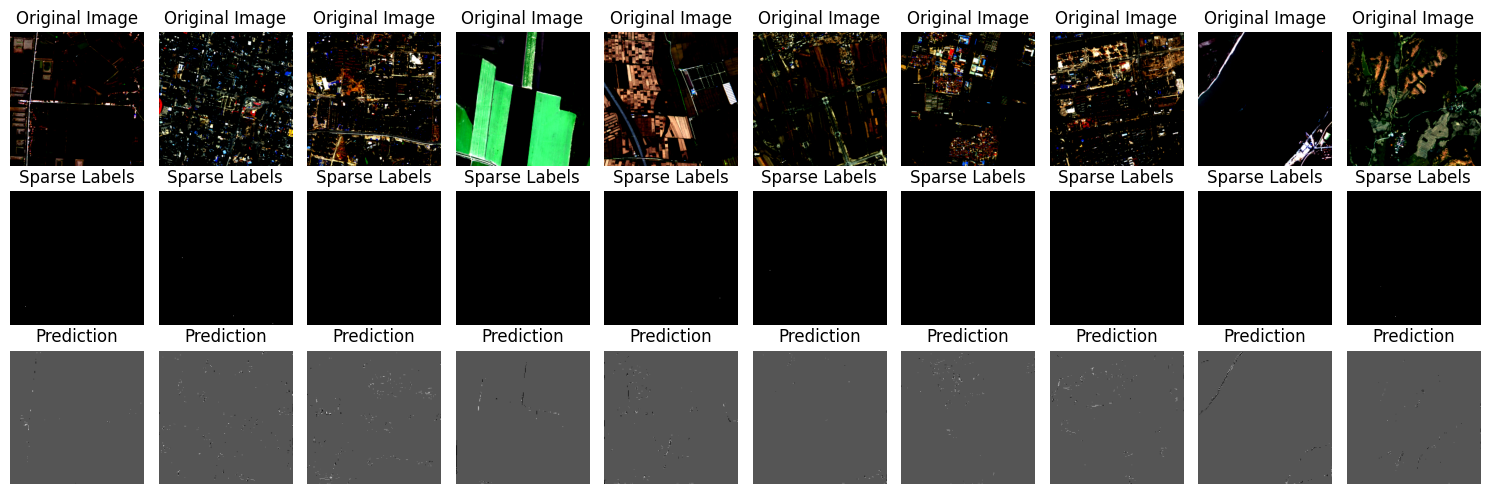

In [40]:
val_loader   = DataLoader(val_dataset, batch_size=bs, shuffle=False, generator=generator)
# visualize predictions using the best model
visualize_predictions(best_model, val_loader)

### Visualizing model predictions on Test set
Visualize and view the model's predictions on unseen data(Test) without comparisons.

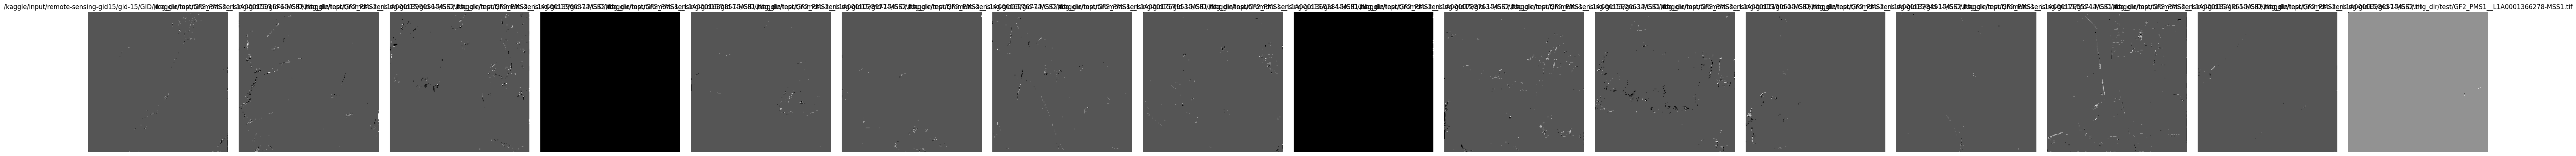

In [42]:
test_loader  = DataLoader(test_dataset, batch_size=bs, shuffle=False, generator=generator)
# generate predictions on the test set
test_predictions = test_model(best_model, test_loader)

# visualize test predictions
visualize_test_predictions(test_predictions)